In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))


In [3]:
data = {
    # "train": {
    #     "images": [],
    #     "ground_truth": [],
    #     "predicted_mask": []
    # },
    # "validation": {
    #     "images": [],
    #     "ground_truth": [],
    #     "predicted_mask": []
    # },
    "test": {
        "images": [],
        "ground_truth": [],
        "predicted_mask": []
    }
}

base_path = os.path.abspath(os.path.join(os.getcwd(), "../../../data/SCLabels_oblique_prediction_deeplab_256x1024/")) # 

sub_dirs = ["train", "validation", "test"]
sub_dirs = ["test"]

for sub_dir in sub_dirs:
    for file in os.listdir(os.path.join(base_path, "images", sub_dir)):
        if file.endswith(".jpg"):
            path = os.path.join(base_path, "images", sub_dir, file)
            data[sub_dir]["images"].append(path)

            file = file.replace("image.jpg", "mask.png")
            path = os.path.join(base_path, "masks", sub_dir, file)
            data[sub_dir]["ground_truth"].append(path)

            if base_path == os.path.abspath(os.path.join(os.getcwd(), "../../data/SCLabels_prediction_by_set_unet/")):
                file = file.replace("mask.png", "pred.png")
            # file = file.replace("mask.png", "pred.png")
            path = os.path.join(base_path, "predicted_mask", sub_dir, file)
            data[sub_dir]["predicted_mask"].append(path)

print("Data loaded")

Data loaded


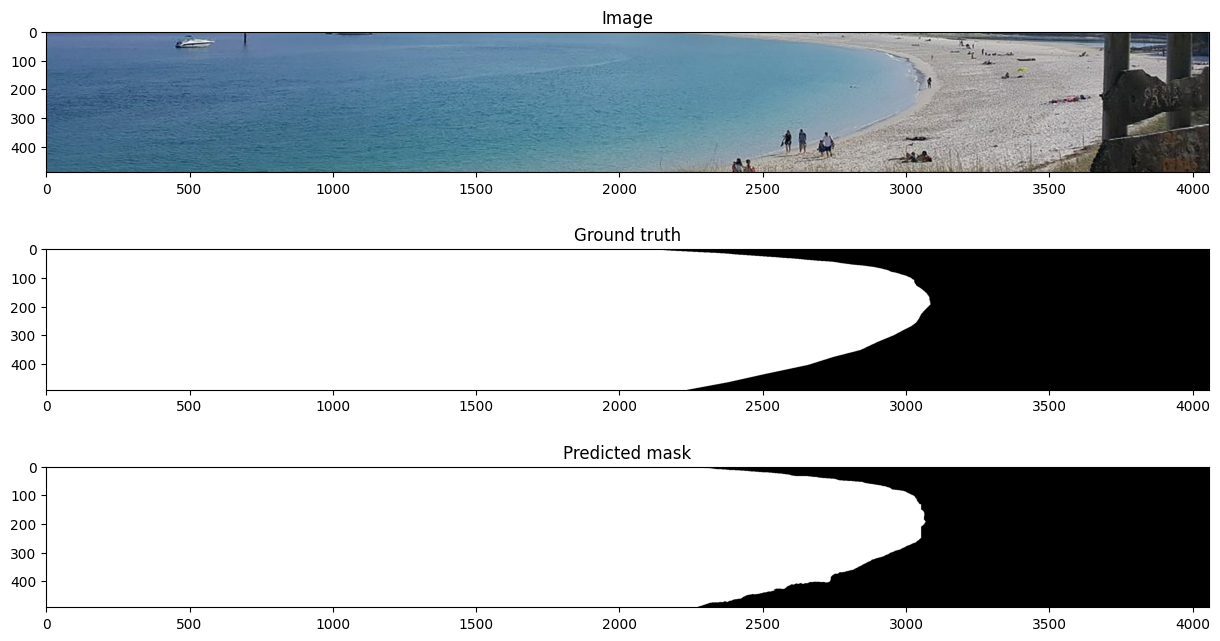

In [4]:
index = 0 # 85 # 160 # 102
img = data["test"]["images"][index]
ground_truth_path = data["test"]["ground_truth"][index]
pred_path = data["test"]["predicted_mask"][index]

img = cv2.imread(img)
ground_truth = cv2.imread(ground_truth_path, cv2.IMREAD_GRAYSCALE)
pred = cv2.imread(pred_path, cv2.IMREAD_GRAYSCALE)

fig, ax = plt.subplots(3, 1, figsize=(15, 8))
ax[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
ax[0].set_title("Image")
ax[1].imshow(ground_truth, cmap="gray", vmin=0, vmax=1)
ax[1].set_title("Ground truth")
ax[2].imshow(pred, cmap="gray", vmin=0, vmax=1)
ax[2].set_title("Predicted mask")
plt.show()

In [6]:
from torchmetrics.classification import (
    MulticlassAccuracy, MulticlassF1Score, MulticlassPrecision, 
    MulticlassRecall
)
import torch

coasts = ["agrelo", "cies", "cadiz", "samarador", "arenaldentem"]
metrics = {}

for coast in coasts:
    metrics[coast] = {
        "accuracy": [],
        "precision": [],
        "recall": [],
        "f1_score": [],
    }

metrics["global"] = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1_score": [],
}

for split in data:
    print(f"Split: {split}")
    if split != "test":
        continue
    for img_path, mask_path, pred_path in zip(data[split]["images"], data[split]["ground_truth"], data[split]["predicted_mask"]):
        # print(img_path)
        # print(mask_path)
        # print(pred_path)
        img = cv2.imread(img_path)
        coast = img_path.split(os.sep)[-1].split("_")[-1].split(".")[3]
        # print(f"Coast: {coast}")
        pred = cv2.imread(pred_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        pred_tensor = torch.from_numpy(pred).long().unsqueeze(0)
        mask_tensor = torch.from_numpy(mask).long().unsqueeze(0)
        # Calculate metrics
        accuracy = MulticlassAccuracy(num_classes=2)(pred_tensor, mask_tensor).item()
        precision = MulticlassPrecision(num_classes=2)(pred_tensor, mask_tensor).item()
        recall = MulticlassRecall(num_classes=2)(pred_tensor, mask_tensor).item()
        f1_score = MulticlassF1Score(num_classes=2)(pred_tensor, mask_tensor).item()

        metrics[coast]["accuracy"].append(accuracy)
        metrics[coast]["precision"].append(precision)
        metrics[coast]["recall"].append(recall)
        metrics[coast]["f1_score"].append(f1_score)

        metrics["global"]["accuracy"].append(accuracy)
        metrics["global"]["precision"].append(precision)
        metrics["global"]["recall"].append(recall)
        metrics["global"]["f1_score"].append(f1_score)
        

        # print(f"Accuracy: {accuracy}")
        # print(f"Precision: {precision}")
        # print(f"Recall: {recall}")
        # print(f"F1 Score: {f1_score}")
        # break

for coast in metrics:
    print(f"Coast: {coast}")
    for metric in metrics[coast]:
        values = metrics[coast][metric]
        mean_value = np.mean(values)
        std_value = np.std(values)
        print(f"  {metric}: {mean_value:.4f} ± {std_value:.4f}")
        

Split: test
Coast: agrelo
  accuracy: 0.9599 ± 0.0799
  precision: 0.9622 ± 0.0764
  recall: 0.9599 ± 0.0799
  f1_score: 0.9575 ± 0.0854
Coast: cies
  accuracy: 0.9891 ± 0.0122
  precision: 0.9878 ± 0.0177
  recall: 0.9891 ± 0.0122
  f1_score: 0.9881 ± 0.0151
Coast: cadiz
  accuracy: 0.9706 ± 0.0183
  precision: 0.9718 ± 0.0182
  recall: 0.9706 ± 0.0183
  f1_score: 0.9703 ± 0.0196
Coast: samarador
  accuracy: 0.8837 ± 0.1420
  precision: 0.9381 ± 0.0509
  recall: 0.8837 ± 0.1420
  f1_score: 0.8821 ± 0.1529
Coast: arenaldentem
  accuracy: 0.9698 ± 0.0131
  precision: 0.9457 ± 0.0357
  recall: 0.9698 ± 0.0131
  f1_score: 0.9551 ± 0.0268
Coast: global
  accuracy: 0.9707 ± 0.0469
  precision: 0.9727 ± 0.0367
  recall: 0.9707 ± 0.0469
  f1_score: 0.9696 ± 0.0501
